# 02 — De AMI a transcripciones legibles y congeladas

**Autor:** Jason Sepúlveda S.
**Depende de:** [`00-jss-corpus-y-auditoria.ipynb`](00-jss-corpus-y-auditoria.ipynb)

---

## Qué hace este notebook

AMI no distribuye transcripciones como archivo de texto: distribuye anotación *stand-off*
NXT, capas separadas de palabras, turnos y actos de diálogo que hay que reconstruir. Este
notebook documenta esa reconstrucción — el paso entre el corpus tal como se descarga y las
transcripciones legibles que van a leer los anotadores humanos, indexar C1 (el documento-RAG)
e ingerir C2 (OpenKOS).

En orden: el problema de origen, el primer intento que falló, las decisiones de render que
hay que declarar en la tesis, el resultado, por qué se congelan dos artefactos y no uno, la
cobertura del corpus completo, y el mecanismo de congelamiento verificable que hace posible
afirmar que anotadores, C1 y C2 vieron exactamente los mismos bytes.

## Qué NO hace este notebook

No toca OpenKOS ni la ingesta a C2. Esa ingesta ocurre después de este congelamiento y en un
orden que tiene su propia razón (sección 8). Tampoco anota nada: sigue sin haber una sola
etiqueta puesta por una persona sobre este texto.

In [1]:
import json
import tomllib

import matplotlib.pyplot as plt
import pandas as pd

from afg.corpus.render import MANIFEST_CSV_NAME, sha256_of_file
from afg.corpus.transcripts import render_meeting_dialogue_acts, render_meeting_transcript
from afg.shared.paths import AMI_DIR, PROJECT_ROOT, TABLES_DIR, TRANSCRIPTS_DIR

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 130)
plt.rcParams.update({"figure.figsize": (9, 4), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

MANIFEST_PATH = TABLES_DIR / MANIFEST_CSV_NAME

# Guarda: el corpus esta en .gitignore y las transcripciones son un artefacto derivado.
if not AMI_DIR.exists() or not any(AMI_DIR.glob("words/*.words.xml")):
    raise SystemExit(
        f"El corpus AMI no esta en {AMI_DIR}.\n"
        "Descargalo primero con:  uv run afg corpus download"
    )
if not TRANSCRIPTS_DIR.exists() or not MANIFEST_PATH.exists():
    raise SystemExit(
        f"No se encontraron transcripciones congeladas en {TRANSCRIPTS_DIR}\n"
        f"ni el manifiesto en {MANIFEST_PATH}.\n"
        "Renderizalas primero con:  uv run afg corpus transcripts"
    )

CFG = tomllib.loads((PROJECT_ROOT / "config" / "corpus.toml").read_text())["oe1"]
OE1_SERIES = CFG["series"]
DEV_SERIES = CFG["development_series"]

print(f"Corpus en           {AMI_DIR.relative_to(PROJECT_ROOT)}")
print(f"Transcripciones en  {TRANSCRIPTS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Manifiesto en       {MANIFEST_PATH.relative_to(PROJECT_ROOT)}")
print(
    "Series de desarrollo (unicas admisibles para mostrar texto en este notebook): "
    f"{', '.join(DEV_SERIES)}"
)

Corpus en           data/raw/ami
Transcripciones en  data/interim/transcripts
Manifiesto en       reports/tables/transcripts_manifest.csv
Series de desarrollo (unicas admisibles para mostrar texto en este notebook): ES2015, IS1004, TS3009


---

# 1. El problema

AMI distribuye **anotación *stand-off* NXT**, no texto plano. La transcripción de una
reunión no existe como archivo único: hay que reconstruirla combinando varias capas que
viven en directorios distintos y se referencian entre sí por identificador, no por
contenido.

Dos capas bastan para ilustrarlo. `words/<reunion>.<hablante>.words.xml` trae un elemento
por token, en orden documental, con su marca de tiempo:

In [2]:
words_path = AMI_DIR / "words" / "IS1004d.A.words.xml"
print(words_path.read_text(encoding="ISO-8859-1").splitlines()[1:6])

['<nite:root nite:id="IS1004d.A.words" xmlns:nite="http://nite.sourceforge.net/">', '   <vocalsound nite:id="IS1004d.A.words0" starttime="2.735" endtime="4.208" type="cough"/>', '   <w nite:id="IS1004d.A.words1" starttime="25.38" endtime="26.0">Okay</w>', '   <w nite:id="IS1004d.A.words2" starttime="26.0" endtime="26.0" punc="true">.</w>', '   <w nite:id="IS1004d.A.words3" starttime="26.0" endtime="26.18">Good</w>']


`segments/<reunion>.<hablante>.segments.xml` trae los turnos con su tiempo de inicio y fin
según quien transcribió el audio, y **enlaza** cada turno a un rango de palabras en el
archivo anterior — nunca contiene el texto mismo:

In [3]:
segments_path = AMI_DIR / "segments" / "IS1004d.A.segments.xml"
print(segments_path.read_text(encoding="ISO-8859-1").splitlines()[1:8])

['<nite:root nite:id="IS1004d.A.segs" xmlns:nite="http://nite.sourceforge.net/">', '   <segment nite:id="IS1004d.sync.4" channel="0" transcriber_start="2.735" transcriber_end="4.208">', '      <nite:child href="IS1004d.A.words.xml#id(IS1004d.A.words0)"/>', '   </segment>', '   <segment nite:id="IS1004d.sync.6" channel="0" transcriber_start="25.344" transcriber_end="27.44">', '      <nite:child href="IS1004d.A.words.xml#id(IS1004d.A.words1)..id(IS1004d.A.words6)"/>', '   </segment>']


Ahí está la indirección completa: el texto de la palabra vive en una capa, el límite del
turno vive en otra, y el enlace entre ambas —`id(IS1004d.A.words1)..id(IS1004d.A.words6)`—
es un **rango inclusivo sobre el orden documental** del archivo de palabras, no un par de
identificadores sueltos. Resolverlo significa expandir ese rango, en orden, contra el índice
de palabras correspondiente. Los actos de diálogo (`dialogueActs/`, usados en la sección 4)
usan exactamente el mismo mecanismo de enlace, apuntando al mismo archivo de palabras con
sus propios rangos, casi siempre más finos que los de los turnos.

---

# 2. Por qué no bastaba con "extraer el texto"

El primer intento de render devolvió **cero segmentos** sobre el corpus real. No fue un
error de un caso límite: fueron tres defectos acumulados, verificables en el historial del
módulo `afg.corpus.transcripts`.

1. El código tomaba la parte del enlace después de `#` tal cual, dejando el envoltorio
   literal `id(...)` — ningún identificador de palabra llegaba a coincidir con el índice.
2. Los rangos `id(a)..id(b)` nunca se expandían a la secuencia de palabras que cubren; se
   trataban como si nombraran solo los dos extremos.
3. **El orden era por archivo de hablante, no cronológico.**

El tercer defecto es el que más importaba, porque no habría fallado de forma visible: habría
producido un archivo con texto. `words/` y `segments/` están organizados un archivo por
hablante, así que iterar "primero todos los turnos de A, luego todos los de B, luego C, luego
D" arma un documento donde **cada participante habla de principio a fin antes de que el
siguiente empiece** — una conversación que ninguna reunión real tuvo jamás. Si C1 (el
documento-RAG de la sección 5.3) hubiera indexado ese orden, cualquier fragmento recuperado
habría mezclado el minuto 2 de un hablante con el minuto 40 de otro presentándolos como
turnos consecutivos, y ninguna métrica de recuperación posterior lo habría delatado como el
artefacto que es. El orden correcto —intercalado por `transcriber_start`— es la primera
decisión de render que hay que declarar, y es el tema de la sección siguiente.

---

# 3. Las decisiones de render, y por qué

Cinco decisiones quedan fijas en `afg.corpus.render` y `afg.corpus.transcripts`, idénticas
para las tres condiciones experimentales (C1, C2, C3). Se declaran aquí porque cada una
tiene una consecuencia medible si se hiciera distinto:

| Decisión | Razón |
|---|---|
| Turnos intercalados por `transcriber_start` | Es la reconstrucción cronológica real de la conversación (sección 2) |
| Etiqueta de hablante = rol (`PM`, `ME`, `UI`, `ID`) | La sección 6.3 de la propuesta estratifica el análisis por rol, no por letra de hablante |
| Rellenos `uh`/`um` conservados | La capa que permitiría limpiarlos de forma principiada no cubre el conjunto completo (ver más abajo) |
| Elementos no léxicos (`vocalsound`, `disfmarker`, `gap`, `pause`) fuera del texto, pero con su índice documental conservado | Si se descartan del índice y no solo del texto, todo rango posterior que los cruce se desplaza y el resto de la reunión se corrompe en silencio |
| Sin marcas de tiempo dentro del texto | Van en el `.jsonl` (sección 5), no en el cuerpo legible |

La justificación de "rellenos conservados" es medible, no una preferencia de estilo. AMI trae
una capa `disfluency/` que permitiría limpiar rellenos de forma principiada, pero no cubre
las 14 series de OE1 por igual — y esto se verifica contando archivos, no parseando su
contenido:

In [4]:
disfluency_dir = AMI_DIR / "disfluency"
archivos_disfluency = disfluency_dir.glob("*.disfluency.xml")
series_con_disfluency = sorted({p.name.split(".")[0][:6] for p in archivos_disfluency})
oe1_con_disfluency = sorted(set(series_con_disfluency) & set(OE1_SERIES))

print(f"Series de OE1 con capa 'disfluency': {len(oe1_con_disfluency)} de {len(OE1_SERIES)}")
print(", ".join(oe1_con_disfluency))

Series de OE1 con capa 'disfluency': 5 de 14
ES2002, ES2008, IS1003, IS1009, TS3005


Limpiar rellenos apoyándose en esa capa sesgaría exactamente esas cinco series y dejaría
las otras nueve sin tocar — una limpieza pareja sobre un conjunto desigual. Por eso no se
limpia nada aquí: los `uh`/`um` son elementos `<w>` genuinos y quedan en el texto tal como el
corpus los transcribió.

---

# 4. El resultado

**Advertencia de alcance.** A partir de aquí, todo texto transcrito que se muestre proviene
de **IS1004d** (serie IS1004) o **ES2015a** (serie ES2015) — ambas de **desarrollo** según la
partición desarrollo/evaluación (`notebooks/README.md`, "Regla de alcance"; ADR
[0005](../docs/decisions/0005-adr-development-evaluation-split.md)). Ningún fragmento de
texto de una serie de evaluación aparece en este ni en ningún otro notebook.

`render_meeting_transcript` da el nivel de turno — la unidad que consumen C1 y C2:

In [5]:
MEETING_DEMO = "IS1004d"
assert MEETING_DEMO[:6] in DEV_SERIES, "fuera del alcance de desarrollo declarado arriba"

turnos = render_meeting_transcript(AMI_DIR, MEETING_DEMO)
df_turnos = pd.DataFrame(
    {"hablante": t.role_label, "inicio_s": round(t.start_time, 1), "texto": t.text}
    for t in turnos[:8]
)
display(df_turnos)

,hablante,inicio_s,texto
0,PM,25.3,Okay. Good afternoon again.
1,PM,28.4,So we should have our final meeting about the detail designed of detail design of the ...
2,PM,87.2,So we went through th uh w we took this following decisions.
3,PM,93.7,"No L_C_D_, no speech recognition technology, okay, we went through a b to a banana loo..."
4,PM,124.4,So guys
5,PM,127.9,let this uh wonderful thing.
6,ID,131.9,Okay so we can go to the slides. Yeah.
7,PM,133.8,Oh yeah. Sorry. Um.


`render_meeting_dialogue_acts` da el nivel de acto de diálogo — más fino, y anclado a su
propio `nite:id`. Sobre la misma ventana de tiempo, un turno se parte en varios actos:

In [6]:
actos = render_meeting_dialogue_acts(AMI_DIR, MEETING_DEMO)
df_actos = pd.DataFrame(
    {
        "hablante": a.role_label,
        "acto_id": a.dialogue_act_id,
        "inicio_s": round(a.start_time, 1),
        "texto": a.text,
    }
    for a in actos[:8]
)
display(df_actos)

,hablante,acto_id,inicio_s,texto
0,PM,IS1004d.A.dialog-act.dharshi.2,25.4,Okay.
1,PM,IS1004d.A.dialog-act.dharshi.3,26.0,Good afternoon again.
2,PM,IS1004d.A.dialog-act.dharshi.4,28.4,So we should have our final meeting about the detail designed of detail design of the ...
3,PM,IS1004d.A.dialog-act.dharshi.5,41.2,Um So here is the agenda for today.
4,PM,IS1004d.A.dialog-act.dharshi.6,45.3,Uh uh just going to go quickly through the minutes of the last last uh meeting
5,PM,IS1004d.A.dialog-act.dharshi.7,50.7,"then we have a p presentation of prototype of you two,"
6,PM,IS1004d.A.dialog-act.dharshi.8,55.1,sounds interesting.
7,PM,IS1004d.A.dialog-act.dharshi.9,57.3,And we'll have um presentation of evaluation crit criteria by ou our Marketing Experts.


---

# 5. Dos artefactos, no uno

`afg corpus transcripts` escribe dos archivos por reunión, no uno. El `.md` —turnos,
etiquetados por rol, en texto corrido— es lo que un anotador lee y lo que C1/C2 ingieren. Por
sí solo alcanzaría para eso.

No alcanza para lo que viene después. El conjunto de referencia de OE1 ancla cada frase del
resumen abstractivo a los actos de diálogo que la respaldan, vía
`extractive/<reunion>.summlink.xml`. Sin los `dialogue_act_ids` de cada turno, el protocolo
de alineamiento (sección 5.4 de la propuesta) no tiene con qué comparar la salida de un
sistema contra esa evidencia, y la atribución de error de OE4 tampoco tiene a qué etapa
apuntar. El `.jsonl` es esa segunda pieza: mismo texto, con `char_start`/`char_end` situando
cada turno dentro del cuerpo del `.md` y `dialogue_act_ids` haciendo de puente hacia el
resumen.

El `.md` empieza con front matter de texto plano, sin dependencia de YAML, seguido del
cuerpo:

In [7]:
md_path = TRANSCRIPTS_DIR / f"{MEETING_DEMO}.md"
print(md_path.read_text(encoding="utf-8")[:420])

---
meeting_id: IS1004d
series: IS1004
letter: d
source: ami_public_manual_1.6.2
licence: CC BY 4.0
renderer: afg.corpus.render@7d479d2c692a
speakers:
  A: PM
  B: UI
  C: ID
  D: ME
turns: 630
characters: 29364
---

PM: Okay. Good afternoon again.

PM: So we should have our final meeting about the detail designed of detail design of the product of the remote control. Um So here is the agenda for today. Uh uh just go


El `.jsonl` correspondiente tiene un objeto JSON por turno; este es el primero:

In [8]:
jsonl_path = TRANSCRIPTS_DIR / f"{MEETING_DEMO}.jsonl"
primer_registro = json.loads(jsonl_path.read_text(encoding="utf-8").splitlines()[0])
print(json.dumps(primer_registro, indent=2, ensure_ascii=False, sort_keys=True))

{
  "char_end": 31,
  "char_start": 4,
  "dialogue_act_ids": [
    "IS1004d.A.dialog-act.dharshi.2",
    "IS1004d.A.dialog-act.dharshi.3"
  ],
  "end": 27.44,
  "meeting_id": "IS1004d",
  "role": "PM",
  "speaker": "A",
  "start": 25.344,
  "text": "Okay. Good afternoon again.",
  "turn_index": 0
}


`dialogue_act_ids` no es una búsqueda directa: turnos y actos son dos segmentaciones
distintas de la misma secuencia de palabras y no coinciden en dónde cortan. Cada id que
aparece ahí es un acto del mismo hablante cuyo rango de palabras **se superpone** con el del
turno — por eso el primer turno de arriba, con un solo `.` de por medio, ya trae dos actos de
diálogo distintos.

---

# 6. Cobertura del corpus

Las cifras de esta sección son **estructurales** (conteos y coberturas), no de contenido:
se leen del manifiesto agregado, no de ningún texto de reunión, y por eso —a diferencia de la
sección 4— cubren el corpus completo, no solo desarrollo.

In [9]:
manifest = pd.read_csv(MANIFEST_PATH)
manifest["prefijo"] = manifest["series"].str[:2]

def miles(n):
    return f"{n:,}".replace(",", ".")

print(f"Reuniones en el manifiesto: {miles(len(manifest))}")
print(f"Turnos totales:             {miles(int(manifest['turns'].sum()))}")
print(f"Caracteres totales:         {miles(int(manifest['characters'].sum()))}")

Reuniones en el manifiesto: 171
Turnos totales:             83.868
Caracteres totales:         5.429.041


**Las 32 reuniones sin actos de diálogo** importan porque delimitan el marco muestral: son
las reuniones no-escenario del corpus, y ninguna de las 14 series de OE1 está entre ellas.

In [10]:
sin_actos = manifest[manifest["dialogue_acts"] == 0]
print(f"Reuniones sin actos de dialogo: {len(sin_actos)}")
print(f"Prefijos que las contienen:     {sorted(sin_actos['prefijo'].unique())}")

# Excepcion notable: no todo prefijo no-escenario carece de actos de dialogo por completo.
excepcion = manifest[manifest["prefijo"].isin(["EN", "IB", "IN"]) & (manifest["dialogue_acts"] > 0)]
display(excepcion[["meeting_id", "series", "dialogue_acts", "turns"]])

Reuniones sin actos de dialogo: 32
Prefijos que las contienen:     ['EN', 'IB', 'IN']


,meeting_id,series,dialogue_acts,turns
78,IB4003,IB4003,834,390


Las 32 reuniones sin actos de diálogo tienen, en efecto, prefijo `EN`, `IB` o `IN` —
grabaciones fuera del escenario de diseño del control remoto, fuera del marco muestral de
OE1. La única salvedad, visible arriba, es `IB4003`: una reunión no-escenario que sí trae
actos de diálogo. No cambia la conclusión — sigue fuera de las 14 series de OE1 — pero vale
declararla en vez de redondear la regla.

**Las 56 reuniones de las 14 series de OE1** son la contraparte: la condición para poder
anclar cada decisión anotada a su evidencia es que *todas*, sin excepción, tengan actos de
diálogo.

In [11]:
oe1 = manifest[manifest["series"].isin(OE1_SERIES)]
print(f"Reuniones de las 14 series de OE1: {len(oe1)}")
print(f"De ellas, con actos de dialogo:    {(oe1['dialogue_acts'] > 0).sum()} (sin excepcion)")

Reuniones de las 14 series de OE1: 56
De ellas, con actos de dialogo:    56 (sin excepcion)


Resumen por prefijo de serie, corpus completo:

In [12]:
resumen_prefijo = (
    manifest.groupby("prefijo")
    .agg(
        reuniones=("meeting_id", "count"),
        con_actos=("dialogue_acts", lambda s: int((s > 0).sum())),
        turnos=("turns", "sum"),
        caracteres=("characters", "sum"),
    )
    .reset_index()
)
display(resumen_prefijo)

,prefijo,reuniones,con_actos,turnos,caracteres
0,EN,16,0,11671,904288
1,ES,60,60,23222,1622197
2,IB,7,1,4254,259144
3,IN,10,0,6302,483394
4,IS,38,38,15057,908602
5,TS,40,40,23362,1251416


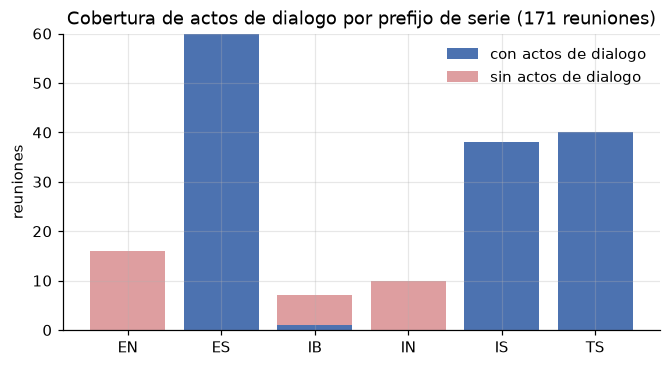

In [13]:
resumen_prefijo["sin_actos"] = resumen_prefijo["reuniones"] - resumen_prefijo["con_actos"]

fig, ax = plt.subplots(figsize=(7, 3.5), dpi=110)
ax.bar(resumen_prefijo["prefijo"], resumen_prefijo["con_actos"],
       label="con actos de dialogo", color="#4C72B0")
ax.bar(resumen_prefijo["prefijo"], resumen_prefijo["sin_actos"],
       bottom=resumen_prefijo["con_actos"], label="sin actos de dialogo",
       color="#C44E52", alpha=0.55)
ax.set_ylabel("reuniones")
ax.set_title("Cobertura de actos de dialogo por prefijo de serie (171 reuniones)")
ax.legend(frameon=False)
plt.show()

---

# 7. El congelamiento

Tres audiencias distintas van a leer este texto: los anotadores humanos de OE1, C1 (que lo
indexa) y C2/OpenKOS (que lo ingiere). La afirmación de que las tres vieron **exactamente los
mismos bytes** solo tiene valor si es verificable después del hecho, no solo cierta en el
momento de renderizar. Para eso existe el manifiesto: por cada reunión guarda el SHA-256 del
`.md` y del `.jsonl`, más `renderer_revision` — el commit de `src/afg/corpus/` que produjo
ese render.

In [14]:
display(manifest.loc[manifest["meeting_id"].isin(["IS1004d", "ES2015a", "TS3009a"]),
                      ["meeting_id", "sha256_md", "sha256_jsonl", "renderer_revision"]])

,meeting_id,sha256_md,sha256_jsonl,renderer_revision
68,ES2015a,f7096938ea22298d1c25f4fd8a708c23c476bfb1b3c24b8e5e5f6d8bdbed36ef,e56d9fec1a09c48f090fc96cccdfd8dbffafb9875ae5c849215e4ef97dce3b7a,7d479d2c692a
111,IS1004d,3c74bdd92a7a734b0ce4f401c902213ba519355eef0eb89a8db48f8ffe990963,45adf8fcefc835b0a0dd357f68d92c838396d827efa390b8cd45373cadd9d2f3,7d479d2c692a
155,TS3009a,6d087bc2b6fd9097d97eb71e5f6da5db7f107aa65d79ea7d5f97b0d6fc77ab4f,3312a216bc5d08f3b216f11dcae55106ecf47ae672c4809d48c2ec5e53ba406f,7d479d2c692a


La verificación es directa: recalcular el hash de los archivos en disco con la misma función que los escribió, y compararlo contra la fila del manifiesto.

In [15]:
fila = manifest.loc[manifest["meeting_id"] == MEETING_DEMO].iloc[0]
hash_md_actual = sha256_of_file(md_path)
hash_jsonl_actual = sha256_of_file(jsonl_path)

print(f"sha256_md coincide con el manifiesto:    {hash_md_actual == fila['sha256_md']}")
print(f"sha256_jsonl coincide con el manifiesto: {hash_jsonl_actual == fila['sha256_jsonl']}")

sha256_md coincide con el manifiesto:    True
sha256_jsonl coincide con el manifiesto: True


Llegar a que esto sea cierto de forma estable —no solo la primera vez— costó encontrar y
corregir tres trampas de reproducibilidad:

- **`csv.writer` escribe CRLF por defecto, y git lo normaliza a LF al hacer commit.** Sin
  forzar `lineterminator="\n"` al escribir el manifiesto, el archivo recién escrito en disco
  nunca habría coincidido byte a byte con el que queda en el checkout — un desajuste que solo
  aparecería al comparar, no al escribir.
- **`git status --porcelain` sin acotar cuenta cualquier archivo sin seguimiento del
  repositorio.** Sin restringirlo a las rutas que de verdad pueden cambiar el render
  (`src/afg/corpus/`, `src/afg/shared/paths.py`), el propio render anterior —que deja el
  manifiesto y los `.md`/`.jsonl` modificados— marcaría el siguiente render como `-dirty`,
  aunque el código no hubiera cambiado en nada.
- **Usar `HEAD` como revisión del renderizador es circular.** Comitear el manifiesto mueve
  `HEAD`; eso reescribiría el campo `renderer:` del front matter de cada `.md`; eso cambiaría
  cada `sha256_md` del propio manifiesto que se acaba de comitear. El render nunca convergería
  a un punto fijo. La revisión se toma en cambio del último commit que tocó las rutas que
  pueden cambiar el render, nunca de `HEAD`.

La propiedad resultante es la que hace útil al manifiesto: **volver a renderizar sobre un
corpus sin cambios deja `git status` vacío.** No es una promesa; es lo que las dos
comparaciones de arriba, ejecutadas ahora mismo sobre el corpus real, acaban de confirmar.

---

# 8. Qué queda pendiente

Lo que este notebook estableció:

- El primer intento de render fallaba por tres defectos acumulados; el orden cronológico
  entre hablantes era el que más importaba, porque su falla no se habría notado.
- Cinco decisiones de render quedan fijas y declaradas, con su razón — incluida una
  justificación medible (no estilística) para conservar los rellenos.
- Dos artefactos por reunión, no uno: el `.jsonl` es lo que hace posible anclar cada decisión
  a su evidencia en la sección 5.4.
- 171 reuniones renderizadas; 56 de ellas (las 14 series de OE1) con actos de diálogo sin
  excepción; 32 fuera del marco muestral por no pertenecer al escenario.
- El congelamiento por SHA-256 es verificable después del hecho, no solo cierto al momento de
  escribir.

Lo que sigue, fuera del alcance de este notebook:

- **Congelar antes de que empiece la anotación humana de OE1** — los anotadores trabajan
  sobre estos mismos bytes, y cualquier re-render posterior invalidaría en silencio los
  `char_start`/`char_end` que ya hubieran citado.
- **La ingesta a OpenKOS (C2) es serie por serie, en orden `a → b → c → d`.** La sección 5.1
  de la propuesta prohíbe consultar reuniones futuras al procesar una anterior; ingerir fuera
  de ese orden filtraría información que el sistema bajo evaluación no debería tener todavía.
  Esa ingesta no ocurre en este notebook.